In [1]:
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import cuda

In [2]:
def describe_gpu():
    if not cuda.is_available():
        raise RuntimeError("CUDA недоступна. Проверьте, что среда запущена с GPU.")

    gpu = cuda.get_current_device()
    print("CUDA reduction benchmark")
    print("-" * 42)
    print(f"Device: {gpu.name}")
    print(f"Threads per block limit: {gpu.MAX_THREADS_PER_BLOCK}")
    print("-" * 42)


describe_gpu()

CUDA reduction benchmark
------------------------------------------
Device: Tesla T4
Threads per block limit: 1024
------------------------------------------


In [3]:
BLOCK_SIZE = 256


@cuda.jit
def block_reduce_sum(input_data, partial_data, n):
    local_id = cuda.threadIdx.x
    global_id = cuda.blockIdx.x * cuda.blockDim.x + local_id
    step = cuda.blockDim.x * cuda.gridDim.x

    shared = cuda.shared.array(BLOCK_SIZE, dtype=np.float32)

    acc = 0.0

    i = global_id
    while i < n:
        acc += input_data[i]
        i += step

    shared[local_id] = acc
    cuda.syncthreads()

    stride = cuda.blockDim.x // 2
    while stride > 0:
        if local_id < stride:
            shared[local_id] += shared[local_id + stride]
        cuda.syncthreads()
        stride //= 2

    if local_id == 0:
        partial_data[cuda.blockIdx.x] = shared[0]

In [5]:
def python_loop_sum(values):
    start = time.perf_counter()

    total = 0.0
    for item in values:
        total += float(item)

    elapsed = time.perf_counter() - start
    return total, elapsed


def numpy_sum(values):
    start = time.perf_counter()
    total = float(np.sum(values, dtype=np.float64))
    elapsed = time.perf_counter() - start
    return total, elapsed


def cuda_sum(values, repeats=5):
    values = np.asarray(values, dtype=np.float32)
    n = values.size

    # перенос исходного массива на GPU выполняется один раз
    d_current = cuda.to_device(values)

    def reduce_once(d_input, length):
        blocks = min(2048, max(1, (length + BLOCK_SIZE - 1) // BLOCK_SIZE))
        d_output = cuda.device_array(blocks, dtype=np.float32)
        block_reduce_sum[blocks, BLOCK_SIZE](d_input, d_output, length)
        return d_output, blocks

    # warm-up
    d_tmp, tmp_len = reduce_once(d_current, n)
    cuda.synchronize()

    timings = []
    final_value = None

    for _ in range(repeats):
        d_work = d_current
        length = n

        start = time.perf_counter()

        while length > 1:
            d_work, length = reduce_once(d_work, length)

        cuda.synchronize()
        timings.append(time.perf_counter() - start)

        final_value = float(d_work.copy_to_host()[0])

    return final_value, float(np.mean(timings))

In [6]:
@dataclass
class ExperimentConfig:
    sizes: tuple = (2**10, 2**12, 2**14, 2**16, 2**18, 2**20, 2**22)
    seed: int = 42
    repeats_gpu: int = 5


config = ExperimentConfig()
rng = np.random.default_rng(config.seed)

print("Vector sizes:", config.sizes)
print("GPU repeats:", config.repeats_gpu)

Vector sizes: (1024, 4096, 16384, 65536, 262144, 1048576, 4194304)
GPU repeats: 5


In [7]:
records = []

for n in config.sizes:
    vector = rng.random(n, dtype=np.float32)

    loop_total, loop_time = python_loop_sum(vector)
    np_total, np_time = numpy_sum(vector)
    gpu_total, gpu_time = cuda_sum(vector, repeats=config.repeats_gpu)

    abs_error = abs(gpu_total - np_total)
    rel_error = abs_error / abs(np_total)

    records.append({
        "N": n,
        "Python loop, s": loop_time,
        "NumPy, s": np_time,
        "CUDA, s": gpu_time,
        "Speedup vs loop": loop_time / gpu_time,
        "GPU abs error": abs_error,
        "GPU rel error": rel_error,
        "Correct": np.isclose(gpu_total, np_total, rtol=1e-4, atol=1e-2),
    })

    print(
        f"N={n:>8} | loop={loop_time:.6f}s | "
        f"cuda={gpu_time:.6f}s | speedup={loop_time / gpu_time:.2f}x | "
        f"ok={records[-1]['Correct']}"
    )

summary = pd.DataFrame(records)
summary

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


N=    1024 | loop=0.000098s | cuda=0.000504s | speedup=0.19x | ok=True
N=    4096 | loop=0.000372s | cuda=0.000228s | speedup=1.63x | ok=True
N=   16384 | loop=0.001390s | cuda=0.000318s | speedup=4.38x | ok=True
N=   65536 | loop=0.005354s | cuda=0.000241s | speedup=22.26x | ok=True
N=  262144 | loop=0.021487s | cuda=0.000350s | speedup=61.32x | ok=True


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


N= 1048576 | loop=0.165475s | cuda=0.000598s | speedup=276.54x | ok=True
N= 4194304 | loop=0.680598s | cuda=0.000480s | speedup=1416.56x | ok=True


,N,"Python loop, s","NumPy, s","CUDA, s",Speedup vs loop,GPU abs error,GPU rel error,Correct
0,1024,0.000098,0.000072,0.000504,0.194760,0.000002,3.699909e-09,True
1,4096,0.000372,0.000037,0.000228,1.630813,0.000043,2.094071e-08,True
2,16384,0.001390,0.000033,0.000318,4.376020,0.000109,1.339960e-08,True
3,65536,0.005354,0.000065,0.000241,22.255887,0.000617,1.880951e-08,True
4,262144,0.021487,0.000224,0.000350,61.322344,0.005977,4.557339e-08,True
5,1048576,0.165475,0.003109,0.000598,276.543078,0.000538,1.026609e-09,True
6,4194304,0.680598,0.004970,0.000480,1416.560168,0.049230,2.347018e-08,True


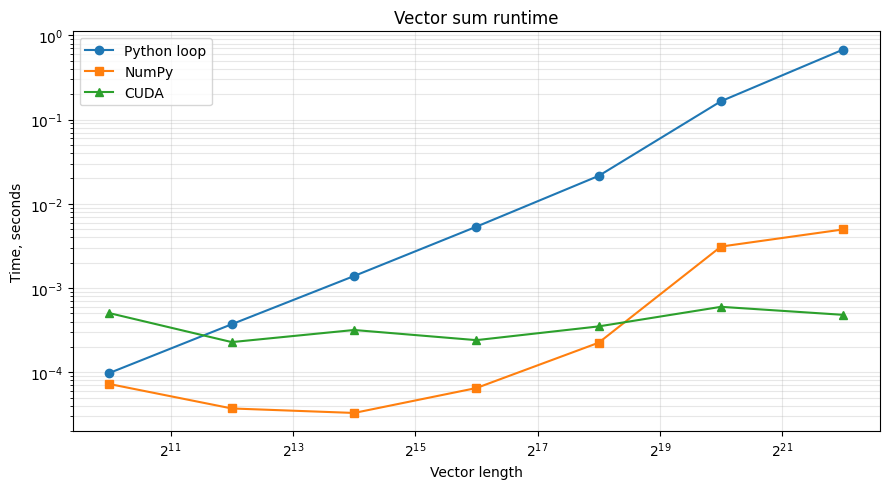

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(summary["N"], summary["Python loop, s"], marker="o", label="Python loop")
plt.plot(summary["N"], summary["NumPy, s"], marker="s", label="NumPy")
plt.plot(summary["N"], summary["CUDA, s"], marker="^", label="CUDA")
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Vector length")
plt.ylabel("Time, seconds")
plt.title("Vector sum runtime")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

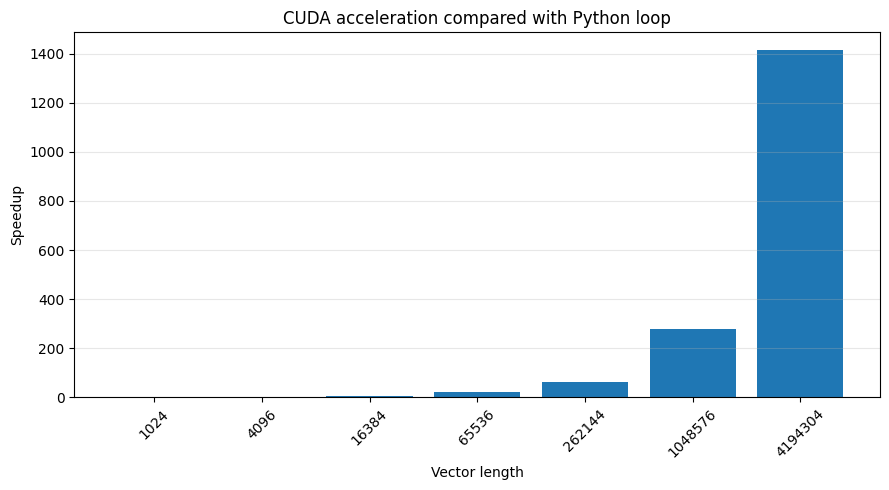

In [9]:
plt.figure(figsize=(9, 5))
plt.bar(summary["N"].astype(str), summary["Speedup vs loop"])
plt.xlabel("Vector length")
plt.ylabel("Speedup")
plt.title("CUDA acceleration compared with Python loop")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
best_row = summary.loc[summary["Speedup vs loop"].idxmax()]

print("Final report")
print("-" * 42)
print(f"Largest tested vector: {int(summary['N'].max())}")
print(f"Maximum speedup: {best_row['Speedup vs loop']:.2f}x")
print(f"Best speedup vector size: {int(best_row['N'])}")
print(f"All CUDA results valid: {bool(summary['Correct'].all())}")
print(f"Maximum relative error: {summary['GPU rel error'].max():.3e}")

Final report
------------------------------------------
Largest tested vector: 4194304
Maximum speedup: 1416.56x
Best speedup vector size: 4194304
All CUDA results valid: True
Maximum relative error: 4.557e-08
